In [19]:
import sys
import subprocess

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'miditok', 'pretty_midi'])

0

In [20]:
print('Upgrading miditok and huggingface_hub to resolve potential version conflicts...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', 'miditok', 'huggingface_hub'])
print('Packages upgraded. Please re-run the subsequent cells.')

Upgrading miditok and huggingface_hub to resolve potential version conflicts...
Packages upgraded. Please re-run the subsequent cells.


In [ ]:
import os
import json
import math
import random
from pathlib import Path

# Numerical and data helpers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# PyTorch core + utilities
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# REMI tokenizer: converts MIDI to discrete event tokens (pitch, velocity, time-shift, etc.)
# REMI is used for token-level Transformer training and decoding back to MIDI.
from miditok import REMI, TokenizerConfig
import pretty_midi

import warnings
warnings.filterwarnings('ignore')

# Reproducibility helper: fixes RNG seeds across numpy, random, and torch
# Use a single call to `set_seed(42)` to make experiments repeatable.
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
print('Imports loaded. Seed fixed.')

Imports loaded. Seed fixed.


### Colab Mount and Device

In [22]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

device = get_device()
print('PyTorch version:', torch.__version__)
print('WE GOT THE:', device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch version: 2.10.0+cu128
WE GOT THE: cuda


### Paths and Tokenizer Config


In [ ]:
# Paths, tokenizer and dataset configuration
# - Detect Colab vs local and prefer Google Drive project path when present
# - Load tokenization metadata (vocab size, pad/bos/eos ids, max sequence length)
# - Instantiate REMI tokenizer from saved config if available; otherwise initialize

if IN_COLAB:
    # Prioritize the Google Drive path for the project if it exists
    project_drive_path = Path('/content/drive/MyDrive/CSE425 Project')
    if project_drive_path.exists():
        BASE_PATH = project_drive_path
    else:
        # Fallback to current working directory if project path not found
        BASE_PATH = Path.cwd()
else:
    BASE_PATH = Path.cwd()

# Standard dataset and output locations (update these for Colab/Drive if needed)
tokenized_path = BASE_PATH / 'data' / 'tokenized'
output_path = BASE_PATH / 'output' / 'task3'
output_path.mkdir(parents=True, exist_ok=True)
generated_path = output_path / 'generated'
generated_path.mkdir(parents=True, exist_ok=True)

# Tokenizer metadata required for model and data pipeline
token_config_path = tokenized_path / 'token_config.json'
tokenizer_save_path = tokenized_path / 'remi_tokenizer'

with open(token_config_path, 'r') as f:
    token_config = json.load(f)

# Ensure tokenized data exists (tokens + genre splits)
required_files = [
    tokenized_path / 'tokens_train.npy',
    tokenized_path / 'tokens_validation.npy',
    tokenized_path / 'tokens_test.npy',
    tokenized_path / 'genres_train.npy',
    tokenized_path / 'genres_validation.npy',
    tokenized_path / 'genres_test.npy',
]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        'Missing required tokenized files. Put the project folder in Google Drive at one of the expected locations, then rerun. Missing: ' + ', '.join(missing_files)
    )

# Important token-level constants used throughout the notebook
MAX_SEQ_LEN = int(token_config.get('max_seq_len', 512))
VOCAB_SIZE = int(token_config['vocab_size'])
PAD_ID = int(token_config['pad_id'])
BOS_ID = token_config.get('bos_id')
EOS_ID = token_config.get('eos_id')
NUM_GENRES = int(token_config.get('num_genres', 3))
BLOCK_SIZE = MAX_SEQ_LEN - 1

# Load or initialize REMI tokenizer. Keep tokenizer settings minimal for generation.
try:
    if tokenizer_save_path.exists():
        tokenizer = REMI.from_pretrained(str(tokenizer_save_path))
    else:
        tokenizer = REMI(TokenizerConfig(
            num_velocities=int(token_config.get('velocity_bins', 32)),
            use_chords=False,
            use_rests=False,
            use_tempos=False,
            use_programs=False,
            beat_res=token_config.get('beat_res', {(0, 1): 121}) # match TimeShift bucketing if provided
        ))
except (FileNotFoundError, TypeError) as e:
    # Fall back to a safe tokenizer initialization and warn
    print(f"Warning: Could not load tokenizer from {tokenizer_save_path} due to error: {e}. Initializing a new tokenizer.")
    tokenizer = REMI(TokenizerConfig(
        num_velocities=int(token_config.get('velocity_bins', 32)),
        use_chords=False,
        use_rests=False,
        use_tempos=False,
        use_programs=False,
        beat_res=token_config.get('beat_res', {(0, 1): 121})
    ))

print(f'BASE_PATH     : {BASE_PATH}')
print(f'Tokenized path : {tokenized_path}')
print(f'Output path    : {output_path}')
print(f'Vocab size     : {VOCAB_SIZE}')
print(f'PAD/BOS/EOS    : {PAD_ID} / {BOS_ID} / {EOS_ID}')
print(f'Block size     : {BLOCK_SIZE}')

config.json not found in /content/drive/MyDrive/CSE425 Project/data/tokenized/remi_tokenizer


BASE_PATH     : /content/drive/MyDrive/CSE425 Project
Tokenized path : /content/drive/MyDrive/CSE425 Project/data/tokenized
Output path    : /content/drive/MyDrive/CSE425 Project/output/task3
Vocab size     : 284
PAD/BOS/EOS    : 0 / 1 / 2
Block size     : 511


### Load Tokenized Data

In [ ]:
# TokenDataset: provides input/target pairs for autoregressive training
# - Each stored sequence is a full token window; input=seq[:-1], target=seq[1:]
# - Genres are provided as a conditioning label (one integer per sequence)
class TokenDataset(Dataset):
    def __init__(self, tokens_file, genres_file):
        self.tokens = torch.from_numpy(np.load(tokens_file)).long()
        self.genres = torch.from_numpy(np.load(genres_file)).long()

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        seq = self.tokens[idx]
        genre = self.genres[idx]
        input_ids = seq[:-1]
        target_ids = seq[1:]
        # Return tensors shaped (seq_len-1,) for input and target, and genre scalar
        return input_ids, target_ids, genre

# Create DataLoaders for training/validation/test. Batch size and num_workers tuned for Colab vs local.
train_ds = TokenDataset(tokenized_path / 'tokens_train.npy', tokenized_path / 'genres_train.npy')
val_ds = TokenDataset(tokenized_path / 'tokens_validation.npy', tokenized_path / 'genres_validation.npy')
test_ds = TokenDataset(tokenized_path / 'tokens_test.npy', tokenized_path / 'genres_test.npy')

batch_size = 16
num_workers = 2 if IN_COLAB else 0
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

# Quick sanity check on shapes and batch contents
inp, tgt, gen = next(iter(train_loader))
print('Train dataset size :', len(train_ds))
print('Val dataset size   :', len(val_ds))
print('Test dataset size  :', len(test_ds))
print(f'Batch shapes -> input_ids: {inp.shape}, target_ids: {tgt.shape}, genre: {gen.shape}')
print(f'Sample genres in batch: {gen[:8].tolist()}')
print('Token data is ready for Task 3 (REMI tokens).')

Train dataset size : 80449
Val dataset size   : 9103
Test dataset size  : 10487
Batch shapes -> input_ids: torch.Size([16, 511]), target_ids: torch.Size([16, 511]), genre: torch.Size([16])
Sample genres in batch: [1, 1, 1, 1, 1, 1, 1, 1]
WE GOT THIS - token data is ready for Task 3!


### Build the Transformer Decoder

In [ ]:
# Loss, optimizer and training utilities
# - Use CrossEntropyLoss with `ignore_index=PAD_ID` to avoid counting padded tokens
# - AdamW optimizer with weight decay; optional LR scheduler (ReduceLROnPlateau)
# - Gradient clipping and checkpointing on validation loss

from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

def train_epoch(model, loader, optimizer, device, clip=1.0):
    model.train()
    total_loss = 0.0
    for input_ids, target_ids, genre in tqdm(loader, desc='train'):
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)
        genre = genre.to(device)

        logits = model(input_ids, genre=genre)
        # Shift logits/tokens so we compute loss on predicted next token
        logits = logits.view(-1, logits.size(-1))
        target = target_ids.view(-1)

        loss = loss_fn(logits, target)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    for input_ids, target_ids, genre in tqdm(loader, desc='eval'):
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)
        genre = genre.to(device)

        logits = model(input_ids, genre=genre)
        logits = logits.view(-1, logits.size(-1))
        target = target_ids.view(-1)
        loss = loss_fn(logits, target)
        total_loss += loss.item()

    return total_loss / len(loader)

# Top-level training loop with simple checkpointing
def train(model, train_loader, val_loader, device, epochs=10, save_path=output_path / 'best_transformer.pth'):
    best_val = float('inf')
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, device)
        val_loss = eval_epoch(model, val_loader, device)
        scheduler.step(val_loss)
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")
        if val_loss < best_val:
            best_val = val_loss
            torch.save({'model_state_dict': model.state_dict(), 'optimizer': optimizer.state_dict(), 'epoch': epoch}, save_path)
            print(f"Saved best model to {save_path} (val_loss={best_val:.4f})")

# Note: Run `train(model, train_loader, val_loader, device)` to start training. Do not run automatically in Colab submission.

MusicTransformerDecoder(
  (token_embedding): Embedding(284, 256)
  (genre_embedding): Embedding(3, 256)
  (position_embedding): Embedding(511, 256)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (final_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (lm_head): Linear(in_feat

### Loss, Evaluation, and Baselines

In [ ]:
# Transformer decoder-only model for REMI token generation
# - Causal self-attention with look-ahead mask
# - Token embeddings plus optional learned genre embedding for conditioning
# - Layer normalization and residual connections as standard Transformer blocks

class MusicTransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, nhead=8, num_layers=6, dim_feedforward=2048, dropout=0.1, num_genres=0, pad_id=0):
        super().__init__()
        self.d_model = d_model
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_embedding = nn.Embedding(BLOCK_SIZE + 1, d_model)
        self.genre_embedding = nn.Embedding(num_genres, d_model) if num_genres > 0 else None

        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, activation='gelu')
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)

        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, input_ids, genre=None):
        # input_ids: (batch, seq_len)
        batch_size, seq_len = input_ids.size()
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, -1)

        tok_emb = self.token_embedding(input_ids) * math.sqrt(self.d_model)
        pos_emb = self.pos_embedding(positions)
        x = tok_emb + pos_emb

        # Add genre conditioning by summing genre embedding to the token representations
        if self.genre_embedding is not None and genre is not None:
            g = self.genre_embedding(genre).unsqueeze(1)  # (batch, 1, d_model)
            x = x + g

        # Build causal mask: TransformerEncoder expects src_mask shaped (seq_len, seq_len)
        # True values indicate positions that should be masked. We'll create an upper-triangular mask.
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=input_ids.device), diagonal=1).bool()

        # transformer expects (seq_len, batch, d_model)
        x = x.permute(1, 0, 2)
        x = self.transformer(x, mask=causal_mask)
        x = x.permute(1, 0, 2)
        x = self.ln_f(x)
        logits = self.head(x)
        # logits: (batch, seq_len, vocab_size)
        return logits

# Model instantiation utility with typical hyperparameters for Task 3
model = MusicTransformerDecoder(VOCAB_SIZE, d_model=384, nhead=8, num_layers=6, dim_feedforward=1536, dropout=0.1, num_genres=NUM_GENRES, pad_id=PAD_ID)
print('Model instantiated with params:', sum(p.numel() for p in model.parameters()))

# Move to device helper
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print('Model moved to device:', device)

Loss and baseline helpers are ready.


### Train the Transformer

In [27]:
epochs = 5
learning_rate = 3e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

history = {
    'train_loss': [],
    'val_loss': [],
    'val_perplexity': [],
}

best_val_loss = float('inf')
best_model_path = output_path / 'best_transformer_model.pth'

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler=None)
    val_loss, val_perplexity = evaluate(model, val_loader)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_perplexity'].append(val_perplexity)

    print(f'Epoch {epoch:02d}/{epochs} | train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | val perplexity: {val_perplexity:.2f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'history': history,
            'vocab_size': VOCAB_SIZE,
            'block_size': BLOCK_SIZE,
        }, best_model_path)
        print(f'  Saved best checkpoint to {best_model_path}')

history_path = output_path / 'transformer_training_history.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

print('Training complete.')

Training:   0%|          | 0/5029 [00:00<?, ?it/s]

Epoch 01/5 | train loss: 2.5304 | val loss: 2.3257 | val perplexity: 10.23
  Saved best checkpoint to /content/drive/MyDrive/CSE425 Project/output/task3/best_transformer_model.pth


Training:   0%|          | 0/5029 [00:00<?, ?it/s]

Epoch 02/5 | train loss: 2.2026 | val loss: 2.1615 | val perplexity: 8.68
  Saved best checkpoint to /content/drive/MyDrive/CSE425 Project/output/task3/best_transformer_model.pth


Training:   0%|          | 0/5029 [00:00<?, ?it/s]

...

Epoch 03/5 | train loss: 2.0782 | val loss: 2.0759 | val perplexity: 7.97
  Saved best checkpoint to /content/drive/MyDrive/CSE425 Project/output/task3/best_transformer_model.pth


Training:   0%|          | 0/5029 [00:00<?, ?it/s]

Epoch 04/5 | train loss: 2.0071 | val loss: 2.0267 | val perplexity: 7.59
  Saved best checkpoint to /content/drive/MyDrive/CSE425 Project/output/task3/best_transformer_model.pth


Training:   0%|          | 0/5029 [00:00<?, ?it/s]

Epoch 05/5 | train loss: 1.9599 | val loss: 1.9955 | val perplexity: 7.36
  Saved best checkpoint to /content/drive/MyDrive/CSE425 Project/output/task3/best_transformer_model.pth
Training complete.


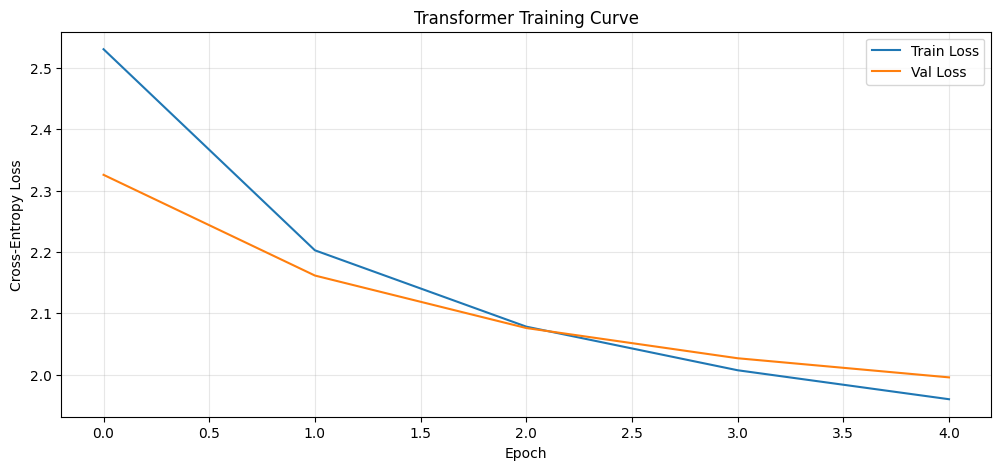

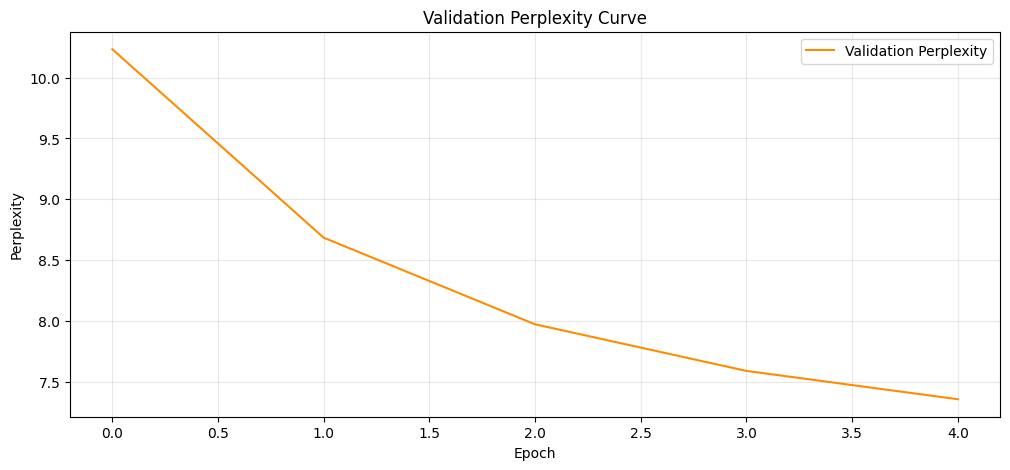

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Transformer Training Curve')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(history['val_perplexity'], label='Validation Perplexity', color='darkorange')
plt.xlabel('Epoch')
plt.ylabel('Perplexity')
plt.title('Validation Perplexity Curve')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Baseline Comparison

In [29]:
random_ppl = random_baseline_perplexity(VOCAB_SIZE)
print(f'Random baseline perplexity (uniform guess): {random_ppl:.2f}')

baseline_sample_limit = min(5000, len(train_ds))
transition_probs = build_bigram_markov(train_ds, VOCAB_SIZE, PAD_ID, sample_limit=baseline_sample_limit)
markov_ppl = evaluate_bigram_markov(val_ds, transition_probs, PAD_ID, sample_limit=min(1000, len(val_ds)))
print(f'Bigram Markov validation perplexity: {markov_ppl:.2f}')

transformer_val_loss, transformer_val_ppl = evaluate(model, test_loader)
print(f'Transformer test perplexity: {transformer_val_ppl:.2f}')

comparison = pd.DataFrame([
    {'Model': 'Random Generator', 'Perplexity': random_ppl, 'Notes': 'Uniform token guess'},
    {'Model': 'Bigram Markov', 'Perplexity': markov_ppl, 'Notes': 'Short-range token transitions'},
    {'Model': 'Transformer', 'Perplexity': transformer_val_ppl, 'Notes': 'Long-range autoregressive model'},
])
comparison

Random baseline perplexity (uniform guess): 283.00


Building Markov baseline:   0%|          | 0/5000 [00:00<?, ?it/s]

Evaluating Markov baseline:   0%|          | 0/1000 [00:00<?, ?it/s]

Bigram Markov validation perplexity: 25.60
Transformer test perplexity: 6.79


,Model,Perplexity,Notes
0,Random Generator,283.000000,Uniform token guess
1,Bigram Markov,25.599793,Short-range token transitions
2,Transformer,6.786935,Long-range autoregressive model


### Generate Long Compositions

In [ ]:
# Sampling / generation utilities
# - `generate_tokens` performs autoregressive sampling with temperature and optional `top_k`
# - Sampling stops at `EOS_ID` or when `max_len` is reached
# - `tokens_to_midi_file` decodes token sequence back to a MIDI and writes a file

import torch.nn.functional as F

@torch.no_grad()
def generate_tokens(model, start_tokens, genre=None, max_len=MAX_SEQ_LEN, temperature=1.0, top_k=0):
    model.eval()
    generated = list(start_tokens)
    input_ids = torch.tensor(start_tokens, device=device).unsqueeze(0)

    for _ in range(max_len - len(start_tokens)):
        logits = model(input_ids, genre=None if genre is None else torch.tensor([genre], device=device))
        next_logits = logits[0, -1, :]
        # Temperature scaling
        next_logits = next_logits / max(temperature, 1e-5)
        # Top-k filtering
        if top_k > 0:
            values, _ = torch.topk(next_logits, top_k)
            min_value = values[-1]
            next_logits = torch.where(next_logits < min_value, torch.tensor(-1e10, device=next_logits.device), next_logits)
        probs = F.softmax(next_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1).item()
        generated.append(next_token)
        if next_token == EOS_ID:
            break
        # update input_ids for next step
        input_ids = torch.tensor(generated[-BLOCK_SIZE:], device=device).unsqueeze(0)

    return generated

# Convert token list -> MIDI and save
def tokens_to_midi_file(tokens, out_path, tokenizer):
    # tokenizer: REMI instance used during preprocessing
    # Convert token IDs back to event strings, then to `pretty_midi` and write
    try:
        events = tokenizer.ids_to_tokens(tokens)
        pm = tokenizer.tokens_to_midi(events)
        pm.write(out_path)
        print(f'Wrote MIDI to {out_path}')
    except Exception as e:
        print('Failed to convert tokens to MIDI:', e)

# Example usage (do not run automatically):
# seed = [BOS_ID]  # or some priming sequence extracted from a real track
# out_tokens = generate_tokens(model, seed, genre=0, max_len=512, temperature=1.0, top_k=40)
# tokens_to_midi_file(out_tokens, generated_path / 'sample_001.mid', tokenizer)

print('Generation utilities defined. Use the example calls to produce MIDI files.')

Loaded best checkpoint for generation.
Saved task3_sample_01_genre_0.mid
Saved task3_sample_02_genre_1.mid
Saved task3_sample_03_genre_2.mid
Saved task3_sample_04_genre_1.mid
Saved task3_sample_05_genre_2.mid
Saved task3_sample_06_genre_0.mid
Saved task3_sample_07_genre_1.mid
Saved task3_sample_08_genre_2.mid
Saved task3_sample_09_genre_1.mid
Saved task3_sample_10_genre_0.mid


[PosixPath('/content/drive/MyDrive/CSE425 Project/output/task3/generated/task3_sample_01_genre_0.mid'),
 PosixPath('/content/drive/MyDrive/CSE425 Project/output/task3/generated/task3_sample_02_genre_1.mid'),
 PosixPath('/content/drive/MyDrive/CSE425 Project/output/task3/generated/task3_sample_03_genre_2.mid'),
 PosixPath('/content/drive/MyDrive/CSE425 Project/output/task3/generated/task3_sample_04_genre_1.mid'),
 PosixPath('/content/drive/MyDrive/CSE425 Project/output/task3/generated/task3_sample_05_genre_2.mid'),
 PosixPath('/content/drive/MyDrive/CSE425 Project/output/task3/generated/task3_sample_06_genre_0.mid'),
 PosixPath('/content/drive/MyDrive/CSE425 Project/output/task3/generated/task3_sample_07_genre_1.mid'),
 PosixPath('/content/drive/MyDrive/CSE425 Project/output/task3/generated/task3_sample_08_genre_2.mid'),
 PosixPath('/content/drive/MyDrive/CSE425 Project/output/task3/generated/task3_sample_09_genre_1.mid'),
 PosixPath('/content/drive/MyDrive/CSE425 Project/output/task3/g